<a href="https://colab.research.google.com/github/devjan-07/Ai-ml-project-/blob/main/06_MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Rice_Leaf_Disease_Project"
)

RAW_DIR = PROJECT_DIR / "01_Raw_Dataset"
NOTEBOOK_DIR = PROJECT_DIR / "02_Notebooks"
RESULTS_DIR = PROJECT_DIR / "03_Results"
REPORT_DIR = PROJECT_DIR / "04_Report"

print("Project folder:", PROJECT_DIR)
print("Raw dataset folder:", RAW_DIR)
print("Notebook folder:", NOTEBOOK_DIR)
print("Results folder:", RESULTS_DIR)
print("Report folder:", REPORT_DIR)

Project folder: /content/drive/MyDrive/Rice_Leaf_Disease_Project
Raw dataset folder: /content/drive/MyDrive/Rice_Leaf_Disease_Project/01_Raw_Dataset
Notebook folder: /content/drive/MyDrive/Rice_Leaf_Disease_Project/02_Notebooks
Results folder: /content/drive/MyDrive/Rice_Leaf_Disease_Project/03_Results
Report folder: /content/drive/MyDrive/Rice_Leaf_Disease_Project/04_Report


In [3]:
DATASET_ZIP = RAW_DIR / "rice leaf diseases dataset.zip"

print("Dataset exists:", DATASET_ZIP.exists())
print("Dataset path:", DATASET_ZIP)

Dataset exists: True
Dataset path: /content/drive/MyDrive/Rice_Leaf_Disease_Project/01_Raw_Dataset/rice leaf diseases dataset.zip


In [4]:
import zipfile

with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
    files = zip_ref.namelist()

print("Total files/folders inside ZIP:", len(files))

print("\nFirst 30 entries:")
for item in files[:30]:
    print(item)

Total files/folders inside ZIP: 5932

First 30 entries:
Bacterialblight/BACTERAILBLIGHT3_001.jpg
Bacterialblight/BACTERAILBLIGHT3_002.jpg
Bacterialblight/BACTERAILBLIGHT3_003.jpg
Bacterialblight/BACTERAILBLIGHT3_004.jpg
Bacterialblight/BACTERAILBLIGHT3_005.jpg
Bacterialblight/BACTERAILBLIGHT3_006.jpg
Bacterialblight/BACTERAILBLIGHT3_007.jpg
Bacterialblight/BACTERAILBLIGHT3_008.jpg
Bacterialblight/BACTERAILBLIGHT3_009.jpg
Bacterialblight/BACTERAILBLIGHT3_010.jpg
Bacterialblight/BACTERAILBLIGHT3_011.jpg
Bacterialblight/BACTERAILBLIGHT3_012.jpg
Bacterialblight/BACTERAILBLIGHT3_013.jpg
Bacterialblight/BACTERAILBLIGHT3_014.jpg
Bacterialblight/BACTERAILBLIGHT3_015.jpg
Bacterialblight/BACTERAILBLIGHT3_016.jpg
Bacterialblight/BACTERAILBLIGHT3_017.jpg
Bacterialblight/BACTERAILBLIGHT3_018.jpg
Bacterialblight/BACTERAILBLIGHT3_019.jpg
Bacterialblight/BACTERAILBLIGHT3_020.jpg
Bacterialblight/BACTERAILBLIGHT3_021.jpg
Bacterialblight/BACTERAILBLIGHT3_022.jpg
Bacterialblight/BACTERAILBLIGHT3_023.jpg
B

In [5]:
import shutil
from pathlib import Path

EXTRACT_DIR = Path("/content/rice_leaf_dataset")

# Remove an old extraction if it exists
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)

# Extract the original ZIP
with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted to:")
print(EXTRACT_DIR)

Dataset extracted to:
/content/rice_leaf_dataset


In [6]:
print("Top-level folders:")

for item in sorted(EXTRACT_DIR.iterdir()):
    if item.is_dir():
        print("📁", item.name)

Top-level folders:
📁 Bacterialblight
📁 Blast
📁 Brownspot
📁 Tungro


In [7]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

In [8]:
# Find all image files in the four disease folders
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

image_records = []

for class_dir in sorted(EXTRACT_DIR.iterdir()):
    if not class_dir.is_dir():
        continue

    class_name = class_dir.name

    for image_path in class_dir.rglob("*"):
        if image_path.is_file() and image_path.suffix.lower() in image_extensions:
            image_records.append({
                "image_path": str(image_path),
                "class_name": class_name
            })

dataset_df = pd.DataFrame(image_records)

print("Total image files:", len(dataset_df))
print("\nClass distribution:")
print(dataset_df["class_name"].value_counts())

Total image files: 5932

Class distribution:
class_name
Brownspot          1600
Bacterialblight    1584
Blast              1440
Tungro             1308
Name: count, dtype: int64


In [9]:
class_counts = (
    dataset_df["class_name"]
    .value_counts()
    .sort_index()
)

print(class_counts)

class_name
Bacterialblight    1584
Blast              1440
Brownspot          1600
Tungro             1308
Name: count, dtype: int64


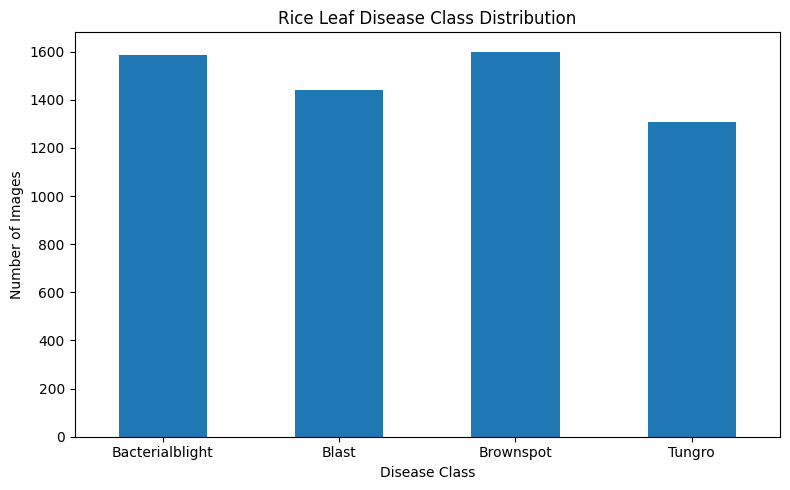

In [10]:
plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.title("Rice Leaf Disease Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
dimension_records = []
corrupt_images = []

for _, row in dataset_df.iterrows():
    image_path = row["image_path"]

    try:
        with Image.open(image_path) as img:
            dimension_records.append({
                "image_path": image_path,
                "class_name": row["class_name"],
                "width": img.width,
                "height": img.height,
                "mode": img.mode
            })

    except (UnidentifiedImageError, OSError):
        corrupt_images.append(image_path)

image_info_df = pd.DataFrame(dimension_records)

print("Readable images:", len(image_info_df))
print("Corrupt/unreadable images:", len(corrupt_images))

print("\nImage modes:")
print(image_info_df["mode"].value_counts())

print("\nMost common image dimensions:")
print(
    image_info_df[["width", "height"]]
    .value_counts()
    .head(15)
)

Readable images: 5932
Corrupt/unreadable images: 0

Image modes:
mode
RGB     5776
RGBA     156
Name: count, dtype: int64

Most common image dimensions:
width  height
300    300       4624
295    221         12
499    332         12
221    295         12
521    348         11
288    216         11
381    571         10
284    426         10
331    497         10
222    296          9
359    538          9
216    288          9
538    359          9
217    289          9
219    292          9
Name: count, dtype: int64


In [12]:
AUDIT_DIR = RESULTS_DIR / "dataset_audit"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

dataset_df.to_csv(
    AUDIT_DIR / "dataset_file_list.csv",
    index=False
)

image_info_df.to_csv(
    AUDIT_DIR / "image_metadata.csv",
    index=False
)

print("Audit files saved to:")
print(AUDIT_DIR)

Audit files saved to:
/content/drive/MyDrive/Rice_Leaf_Disease_Project/03_Results/dataset_audit


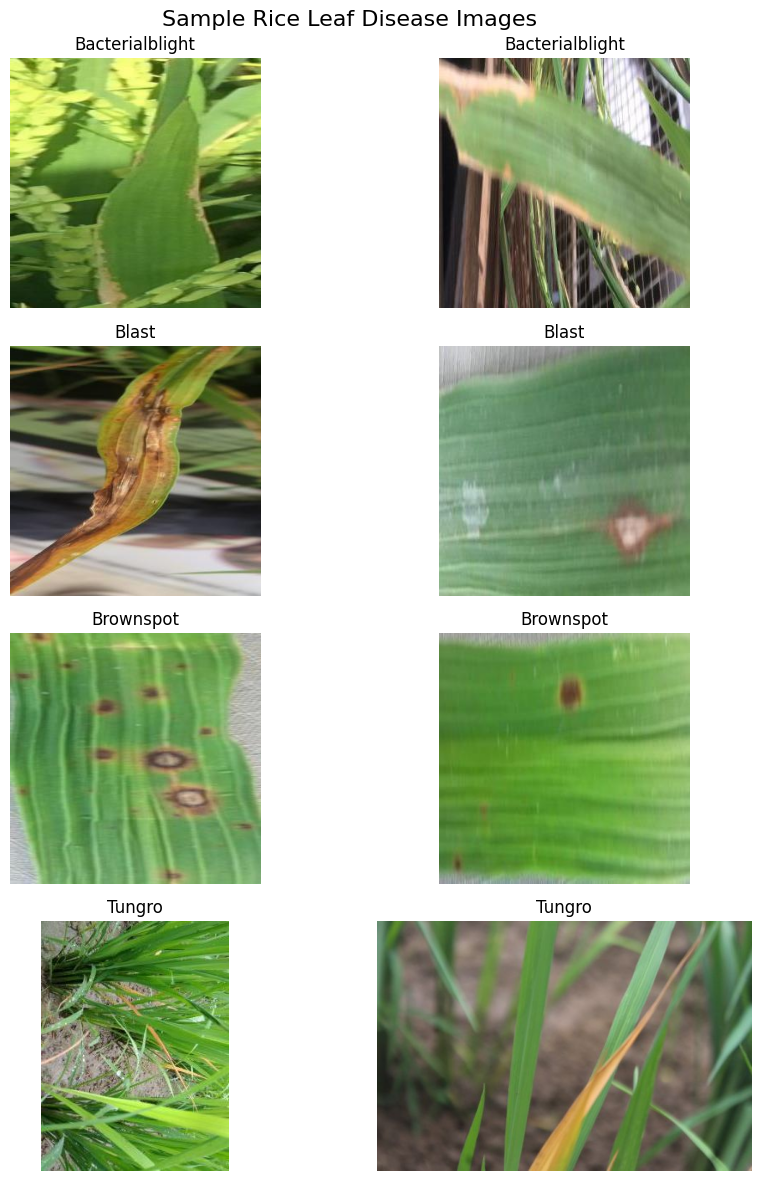

In [13]:
classes = sorted(dataset_df["class_name"].unique())

fig, axes = plt.subplots(
    len(classes),
    2,
    figsize=(10, 12)
)

for row_idx, class_name in enumerate(classes):

    class_images = dataset_df[
        dataset_df["class_name"] == class_name
    ].sample(
        n=2,
        random_state=42
    )

    for col_idx, (_, record) in enumerate(class_images.iterrows()):

        image = Image.open(
            record["image_path"]
        ).convert("RGB")

        axes[row_idx, col_idx].imshow(image)
        axes[row_idx, col_idx].set_title(
            class_name
        )
        axes[row_idx, col_idx].axis("off")

plt.suptitle(
    "Sample Rice Leaf Disease Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [14]:
import hashlib
from collections import defaultdict


def calculate_sha256(file_path, chunk_size=1024 * 1024):
    """
    Calculate the SHA-256 hash of a file.

    SHA-256 allows us to identify files that are
    exactly identical at the binary level.
    """
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        while True:
            data = file.read(chunk_size)

            if not data:
                break

            sha256.update(data)

    return sha256.hexdigest()


# Dictionary:
# hash -> list of image records having that hash
hash_to_images = defaultdict(list)

for _, row in dataset_df.iterrows():
    image_path = row["image_path"]

    try:
        file_hash = calculate_sha256(image_path)

        hash_to_images[file_hash].append({
            "image_path": image_path,
            "class_name": row["class_name"]
        })

    except OSError as error:
        print(f"Could not read: {image_path}")
        print(f"Reason: {error}")


# Keep only hashes that occur more than once.
duplicate_groups = {
    file_hash: records
    for file_hash, records in hash_to_images.items()
    if len(records) > 1
}

print("Total unique file hashes:", len(hash_to_images))
print("Exact duplicate groups:", len(duplicate_groups))
print(
    "Images involved in exact duplicates:",
    sum(len(records) for records in duplicate_groups.values())
)

Total unique file hashes: 4794
Exact duplicate groups: 1096
Images involved in exact duplicates: 2234


In [15]:
for group_number, (file_hash, records) in enumerate(
    duplicate_groups.items(),
    start=1
):
    print(f"\nDuplicate Group {group_number}")
    print(f"Hash: {file_hash}")

    for record in records:
        print(
            f"  {record['class_name']}: "
            f"{record['image_path']}"
        )


Duplicate Group 1
Hash: 27ec70abd8e1fe096f16e17eb98896196bc14e97c2c5205794160ec964b083ec
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERIALBLIGHT1_127.jpg
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERIALBLIGHT1_163.jpg

Duplicate Group 2
Hash: 901ff5becc8b5b33b7c6abe75ad88deec69ffecb60b72849841f2fa1b371ab12
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERAILBLIGHT5_170.jpg
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERAILBLIGHT5_186.jpg
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERAILBLIGHT5_182.jpg
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERAILBLIGHT5_180.jpg
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERAILBLIGHT5_184.jpg

Duplicate Group 3
Hash: 6881ec362e5579b81dddca397415c95cc8f98615602b0a20c7f0a2fbbfafe1b8
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERIALBLIGHT2_256.jpg
  Bacterialblight: /content/rice_l

In [16]:
cross_class_duplicate_groups = {}

for file_hash, records in duplicate_groups.items():

    classes = {
        record["class_name"]
        for record in records
    }

    if len(classes) > 1:
        cross_class_duplicate_groups[file_hash] = records


print(
    "Exact duplicate groups appearing across "
    "multiple classes:",
    len(cross_class_duplicate_groups)
)

Exact duplicate groups appearing across multiple classes: 0


In [17]:
# Create a mapping from image path to its SHA-256 hash.
image_hash_records = []

for _, row in dataset_df.iterrows():
    image_path = row["image_path"]

    try:
        file_hash = calculate_sha256(image_path)

        image_hash_records.append({
            "image_path": image_path,
            "class_name": row["class_name"],
            "file_hash": file_hash
        })

    except OSError as error:
        print(f"Could not read: {image_path}")
        print(f"Reason: {error}")


# Create a dataframe containing hash information.
hashed_df = pd.DataFrame(image_hash_records)

print("Total images before deduplication:", len(hashed_df))
print("Unique images after deduplication:",
      hashed_df["file_hash"].nunique())

Total images before deduplication: 5932
Unique images after deduplication: 4794


In [18]:
# Keep the first occurrence of each exact duplicate group.
deduplicated_df = hashed_df.drop_duplicates(
    subset="file_hash",
    keep="first"
).reset_index(drop=True)


print("Images before deduplication:", len(hashed_df))
print("Images after deduplication:", len(deduplicated_df))
print(
    "Images removed:",
    len(hashed_df) - len(deduplicated_df)
)

Images before deduplication: 5932
Images after deduplication: 4794
Images removed: 1138


In [19]:
deduplicated_class_counts = (
    deduplicated_df["class_name"]
    .value_counts()
    .sort_index()
)

print("Class distribution after deduplication:")
print(deduplicated_class_counts)

Class distribution after deduplication:
class_name
Bacterialblight    1326
Blast               960
Brownspot          1200
Tungro             1308
Name: count, dtype: int64


In [20]:
deduplicated_class_percentages = (
    deduplicated_df["class_name"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nClass percentages after deduplication:")
print(deduplicated_class_percentages.round(2))


Class percentages after deduplication:
class_name
Bacterialblight    27.66
Blast              20.03
Brownspot          25.03
Tungro             27.28
Name: proportion, dtype: float64


In [21]:
duplicate_group_sizes = (
    hashed_df.groupby("file_hash")
    .size()
)

print("Duplicate group size distribution:")
print(
    duplicate_group_sizes[
        duplicate_group_sizes > 1
    ].value_counts().sort_index()
)

Duplicate group size distribution:
2    1078
3       6
5      12
Name: count, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# Step 1: Create the training and temporary datasets
# ---------------------------------------------------------

train_df, temp_df = train_test_split(
    deduplicated_df,
    test_size=0.30,
    stratify=deduplicated_df["class_name"],
    random_state=42
)

# ---------------------------------------------------------
# Step 2: Split the temporary dataset equally
# into validation and testing datasets
# ---------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class_name"],
    random_state=42
)

# Reset dataframe indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ---------------------------------------------------------
# Display dataset sizes
# ---------------------------------------------------------

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))
print("Total images:", len(train_df) + len(val_df) + len(test_df))

Training images: 3355
Validation images: 719
Testing images: 720
Total images: 4794


In [23]:
def show_class_distribution(dataframe, dataset_name):
    """Display class counts and percentages for a dataset split."""

    counts = dataframe["class_name"].value_counts().sort_index()

    percentages = (
        dataframe["class_name"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    distribution = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)
    })

    print(f"\n{dataset_name}")
    print("-" * len(dataset_name))
    print(distribution)


show_class_distribution(train_df, "Training Set")
show_class_distribution(val_df, "Validation Set")
show_class_distribution(test_df, "Test Set")


Training Set
------------
                 Count  Percentage
class_name                        
Bacterialblight    928       27.66
Blast              672       20.03
Brownspot          840       25.04
Tungro             915       27.27

Validation Set
--------------
                 Count  Percentage
class_name                        
Bacterialblight    199       27.68
Blast              144       20.03
Brownspot          180       25.03
Tungro             196       27.26

Test Set
--------
                 Count  Percentage
class_name                        
Bacterialblight    199       27.64
Blast              144       20.00
Brownspot          180       25.00
Tungro             197       27.36


In [24]:
train_paths = set(train_df["image_path"])
val_paths = set(val_df["image_path"])
test_paths = set(test_df["image_path"])

print("Train-Val overlap:", len(train_paths & val_paths))
print("Train-Test overlap:", len(train_paths & test_paths))
print("Val-Test overlap:", len(val_paths & test_paths))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [25]:
from pathlib import Path

import cv2
import pandas as pd


def inspect_image(image_path):
    """
    Inspect an image and return its basic properties.

    Returns:
        dict: Image properties or an error message.
    """
    try:
        image = cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED)

        if image is None:
            return {
                "valid": False,
                "width": None,
                "height": None,
                "channels": None,
                "aspect_ratio": None,
                "format": Path(image_path).suffix.lower(),
                "error": "Could not decode image"
            }

        height, width = image.shape[:2]

        if len(image.shape) == 2:
            channels = 1
        else:
            channels = image.shape[2]

        aspect_ratio = width / height

        return {
            "valid": True,
            "width": width,
            "height": height,
            "channels": channels,
            "aspect_ratio": aspect_ratio,
            "format": Path(image_path).suffix.lower(),
            "error": None
        }

    except Exception as error:
        return {
            "valid": False,
            "width": None,
            "height": None,
            "channels": None,
            "aspect_ratio": None,
            "format": Path(image_path).suffix.lower(),
            "error": str(error)
        }


inspection_results = []

for image_path in deduplicated_df["image_path"]:

    result = inspect_image(image_path)
    result["image_path"] = image_path

    inspection_results.append(result)


image_audit_df = pd.DataFrame(inspection_results)

print("Image audit completed.")
print("Total images inspected:", len(image_audit_df))

Image audit completed.
Total images inspected: 4794


In [26]:
valid_count = image_audit_df["valid"].sum()
invalid_count = (~image_audit_df["valid"]).sum()

print("Valid images:", valid_count)
print("Invalid/corrupted images:", invalid_count)

Valid images: 4794
Invalid/corrupted images: 0


In [27]:
print("\nWidth statistics:")
print(image_audit_df["width"].describe())

print("\nHeight statistics:")
print(image_audit_df["height"].describe())


Width statistics:
count    4794.000000
mean      315.150188
std        59.051438
min       209.000000
25%       300.000000
50%       300.000000
75%       300.000000
max       603.000000
Name: width, dtype: float64

Height statistics:
count    4794.000000
mean      315.100542
std        59.083475
min       209.000000
25%       300.000000
50%       300.000000
75%       300.000000
max       603.000000
Name: height, dtype: float64


In [28]:
dimension_counts = (
    image_audit_df[
        image_audit_df["valid"]
    ]
    .groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
)

print("\nMost common image dimensions:")
print(dimension_counts.head(20))


Most common image dimensions:
width  height
300    300       3486
295    221         12
499    332         12
221    295         12
521    348         11
288    216         11
381    571         10
284    426         10
331    497         10
222    296          9
359    538          9
216    288          9
538    359          9
217    289          9
219    292          9
497    331          9
493    329          9
571    381          9
426    284          9
537    358          8
dtype: int64


In [29]:
print("\nAspect ratio statistics:")
print(
    image_audit_df["aspect_ratio"].describe()
)


Aspect ratio statistics:
count    4794.000000
mean        1.019230
std         0.201614
min         0.663657
25%         1.000000
50%         1.000000
75%         1.000000
max         1.506803
Name: aspect_ratio, dtype: float64


In [30]:
print("\nImages with unusual aspect ratios:")

unusual_aspect_ratios = image_audit_df[
    (image_audit_df["aspect_ratio"] < 0.75) |
    (image_audit_df["aspect_ratio"] > 1.33)
]

print(
    "Number of unusual aspect-ratio images:",
    len(unusual_aspect_ratios)
)


Images with unusual aspect ratios:
Number of unusual aspect-ratio images: 1153


In [31]:
print("\nChannel distribution:")
print(
    image_audit_df["channels"]
    .value_counts()
    .sort_index()
)


Channel distribution:
channels
3    4650
4     144
Name: count, dtype: int64


In [32]:
print("\nImage format distribution:")
print(
    image_audit_df["format"]
    .value_counts()
)


Image format distribution:
format
.jpg    4794
Name: count, dtype: int64


In [33]:
import numpy as np
import tensorflow as tf


# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

IMAGE_SIZE = 224
BATCH_SIZE = 32
RANDOM_SEED = 42

CLASS_NAMES = [
    "Bacterialblight",
    "Blast",
    "Brownspot",
    "Tungro"
]

CLASS_TO_INDEX = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}

NUM_CLASSES = len(CLASS_NAMES)

print("Class mapping:")
for class_name, index in CLASS_TO_INDEX.items():
    print(f"{class_name}: {index}")

print("Number of classes:", NUM_CLASSES)

Class mapping:
Bacterialblight: 0
Blast: 1
Brownspot: 2
Tungro: 3
Number of classes: 4


In [34]:
def create_file_dataset(dataframe):
    """
    Create a TensorFlow dataset containing image paths
    and integer class labels.
    """

    image_paths = dataframe["image_path"].astype(str).values

    labels = dataframe["class_name"].map(
        CLASS_TO_INDEX
    ).values.astype(np.int32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    return dataset


train_raw_ds = create_file_dataset(train_df)
val_raw_ds = create_file_dataset(val_df)
test_raw_ds = create_file_dataset(test_df)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

Training samples: 3355
Validation samples: 719
Testing samples: 720


In [35]:
def load_image(image_path, label):
    """
    Load an image from disk and convert it to RGB.

    Returns:
        image: Tensor with shape (height, width, 3)
        label: Integer class label
    """

    image = tf.io.read_file(image_path)

    image = tf.io.decode_jpeg(
        image,
        channels=3
    )

    image = tf.cast(image, tf.float32)

    return image, label

In [36]:
def resize_image(image, label):
    """
    Resize an image directly to 224 x 224 pixels.
    """

    image = tf.image.resize(
        image,
        size=[224, 224],
        method="bilinear"
    )

    return image, label

In [37]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            mode="horizontal"
        ),
        tf.keras.layers.RandomRotation(
            factor=0.08
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10
        ),
        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        ),
    ],
    name="data_augmentation"
)

In [38]:
def preprocess_for_cnn(
    image_path,
    label,
    training=False
):
    """
    Load, resize, optionally augment, and normalize
    an image for the Custom CNN.
    """

    image, label = load_image(
        image_path,
        label
    )

    image, label = resize_image(
        image,
        label
    )

    image = image / 255.0

    if training:
        image = data_augmentation(
            image,
            training=True
        )

    return image, label

In [39]:
AUTOTUNE = tf.data.AUTOTUNE

train_cnn_ds = (
    train_raw_ds
    .shuffle(
        buffer_size=len(train_df),
        seed=RANDOM_SEED,
        reshuffle_each_iteration=True
    )
    .map(
        lambda image_path, label:
        preprocess_for_cnn(
            image_path,
            label,
            training=True
        ),
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_cnn_ds = (
    val_raw_ds
    .map(
        lambda image_path, label:
        preprocess_for_cnn(
            image_path,
            label,
            training=False
        ),
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_cnn_ds = (
    test_raw_ds
    .map(
        lambda image_path, label:
        preprocess_for_cnn(
            image_path,
            label,
            training=False
        ),
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [40]:
val_images, val_labels = next(iter(val_cnn_ds))

print(val_images.shape)
print(
    tf.reduce_min(val_images).numpy(),
    tf.reduce_max(val_images).numpy()
)

(32, 224, 224, 3)
0.0 1.0


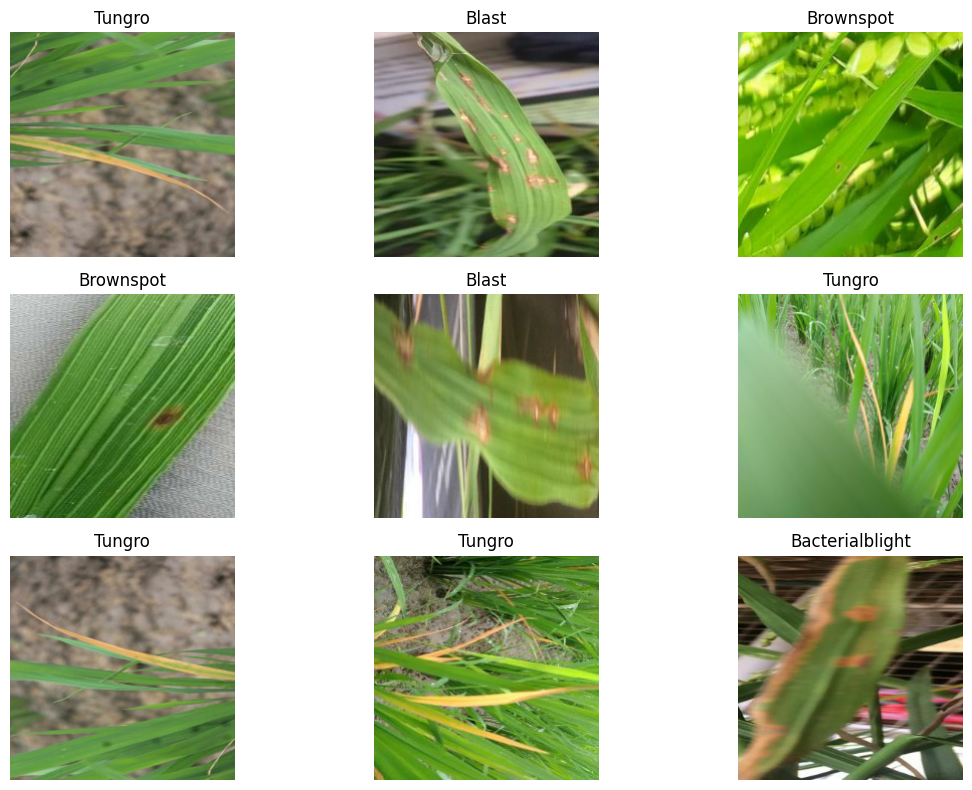

In [41]:
val_images, val_labels = next(iter(val_cnn_ds))

plt.figure(figsize=(12, 8))

for index in range(9):
    plt.subplot(3, 3, index + 1)

    plt.imshow(val_images[index])

    class_index = int(val_labels[index].numpy())

    plt.title(CLASS_NAMES[class_index])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [42]:
images, labels = next(iter(train_cnn_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print(
    "Minimum pixel value:",
    tf.reduce_min(images).numpy()
)

print(
    "Maximum pixel value:",
    tf.reduce_max(images).numpy()
)

print(
    "Unique labels:",
    np.unique(labels.numpy())
)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Unique labels: [0 1 2 3]


In [43]:
images, labels = next(iter(train_cnn_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print(
    "Minimum pixel value:",
    tf.reduce_min(images).numpy()
)

print(
    "Maximum pixel value:",
    tf.reduce_max(images).numpy()
)

print(
    "Unique labels:",
    np.unique(labels.numpy())
)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 0.99995524
Unique labels: [0 1 2 3]


In [44]:
print("Batch labels:")
print(labels.numpy())

print("\nUnique labels in batch:")
print(np.unique(labels.numpy()))

Batch labels:
[1 2 2 3 3 1 2 2 3 0 0 1 1 1 1 2 2 2 1 2 3 0 1 3 2 0 2 2 2 2 2 2]

Unique labels in batch:
[0 1 2 3]


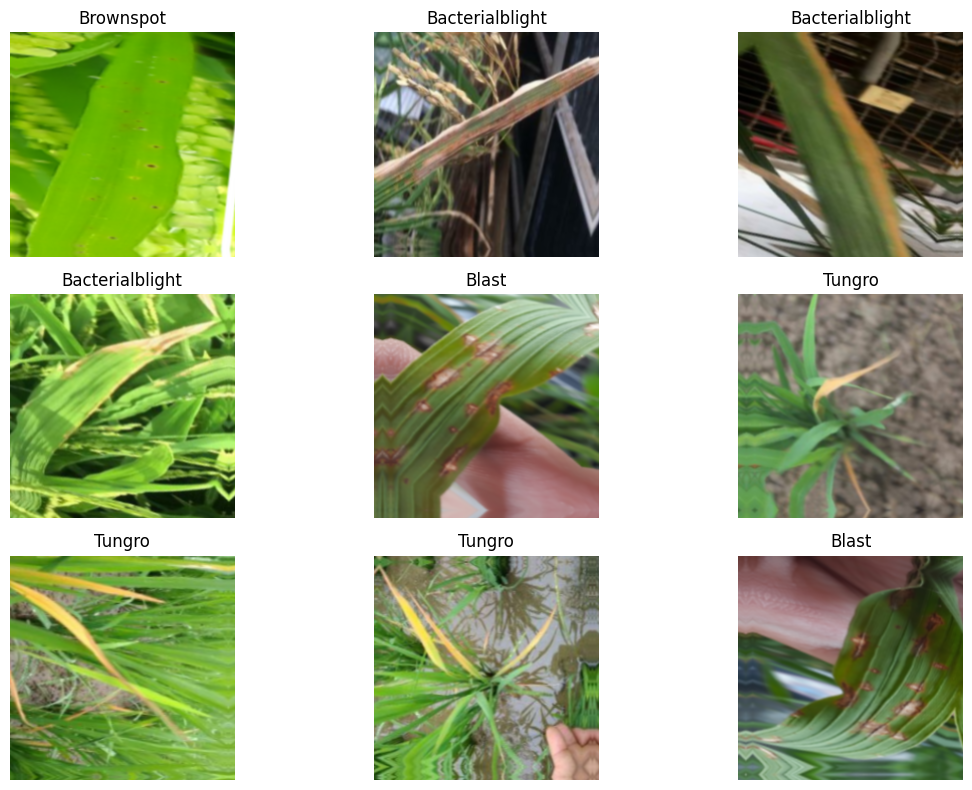

In [45]:
import matplotlib.pyplot as plt


images, labels = next(iter(train_cnn_ds))

plt.figure(figsize=(12, 8))

for index in range(9):
    plt.subplot(3, 3, index + 1)

    plt.imshow(images[index])

    class_index = int(
        labels[index].numpy()
    )

    plt.title(CLASS_NAMES[class_index])
    plt.axis("off")

plt.tight_layout()
plt.show()

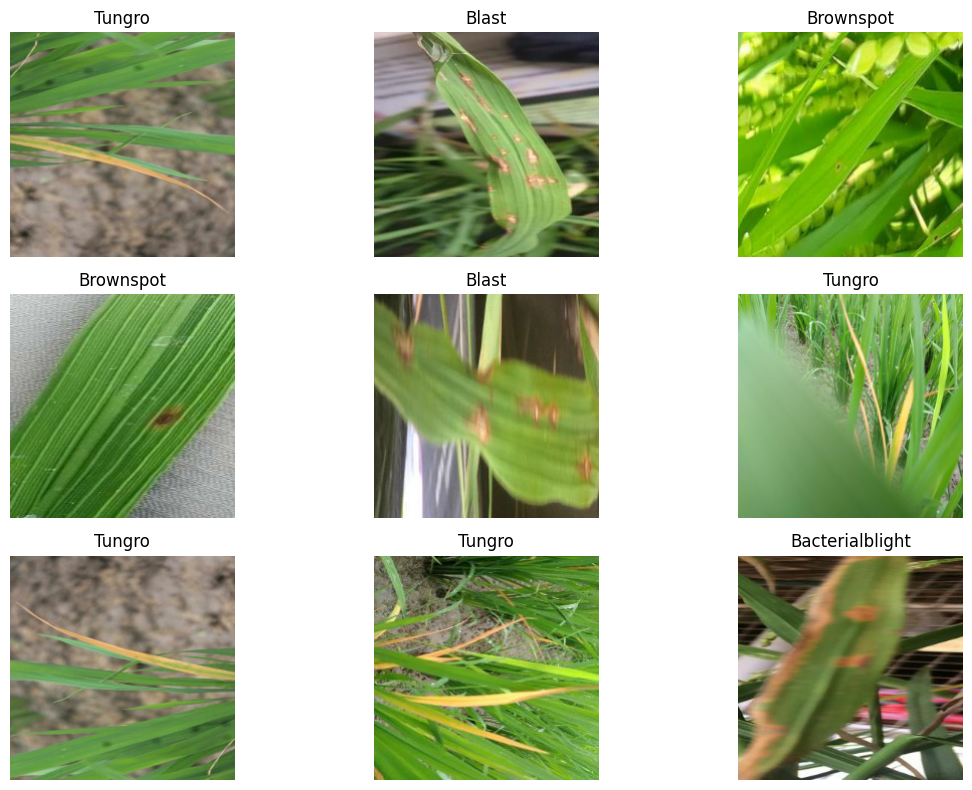

In [46]:
val_images, val_labels = next(iter(val_cnn_ds))

plt.figure(figsize=(12, 8))

for index in range(9):
    plt.subplot(3, 3, index + 1)

    plt.imshow(val_images[index])

    class_index = int(
        val_labels[index].numpy()
    )

    plt.title(CLASS_NAMES[class_index])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [47]:
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input
)

In [48]:
def preprocess_for_mobilenet(
    image_path,
    label,
    training=False
):
    """
    Load, resize, optionally augment, and preprocess
    an image for MobileNetV2.

    Args:
        image_path: Path to the image.
        label: Integer class label.
        training: Whether the image belongs to training data.

    Returns:
        Preprocessed image and integer label.
    """

    image, label = load_image(
        image_path,
        label
    )

    image, label = resize_image(
        image,
        label
    )

    # Apply augmentation only to training images.
    if training:
        image = data_augmentation(
            image,
            training=True
        )

    # MobileNetV2 preprocessing.
    image = preprocess_input(image)

    return image, label

In [49]:
AUTOTUNE = tf.data.AUTOTUNE


train_mobilenet_ds = (
    train_raw_ds
    .shuffle(
        buffer_size=len(train_df),
        seed=RANDOM_SEED,
        reshuffle_each_iteration=True
    )
    .map(
        lambda image_path, label:
        preprocess_for_mobilenet(
            image_path,
            label,
            training=True
        ),
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


val_mobilenet_ds = (
    val_raw_ds
    .map(
        lambda image_path, label:
        preprocess_for_mobilenet(
            image_path,
            label,
            training=False
        ),
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


test_mobilenet_ds = (
    test_raw_ds
    .map(
        lambda image_path, label:
        preprocess_for_mobilenet(
            image_path,
            label,
            training=False
        ),
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [50]:
images, labels = next(iter(train_mobilenet_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print(
    "Minimum pixel value:",
    tf.reduce_min(images).numpy()
)

print(
    "Maximum pixel value:",
    tf.reduce_max(images).numpy()
)

print(
    "Unique labels:",
    np.unique(labels.numpy())
)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: -1.0
Maximum pixel value: 1.0
Unique labels: [0 1 2 3]


In [51]:
val_images, val_labels = next(
    iter(val_mobilenet_ds)
)

print(
    "Validation batch shape:",
    val_images.shape
)

print(
    "Validation label shape:",
    val_labels.shape
)

print(
    "Validation unique labels:",
    np.unique(val_labels.numpy())
)

Validation batch shape: (32, 224, 224, 3)
Validation label shape: (32,)
Validation unique labels: [0 1 2 3]


In [52]:
def display_mobilenet_images(
    images,
    labels
):
    """
    Convert MobileNetV2-preprocessed images back to
    displayable RGB values and visualize them.
    """

    display_images = (
        images + 1.0
    ) * 127.5

    display_images = tf.clip_by_value(
        display_images,
        0.0,
        255.0
    )

    display_images = (
        display_images / 255.0
    )

    plt.figure(figsize=(12, 8))

    for index in range(9):
        plt.subplot(3, 3, index + 1)

        plt.imshow(
            display_images[index]
        )

        class_index = int(
            labels[index].numpy()
        )

        plt.title(
            CLASS_NAMES[class_index]
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

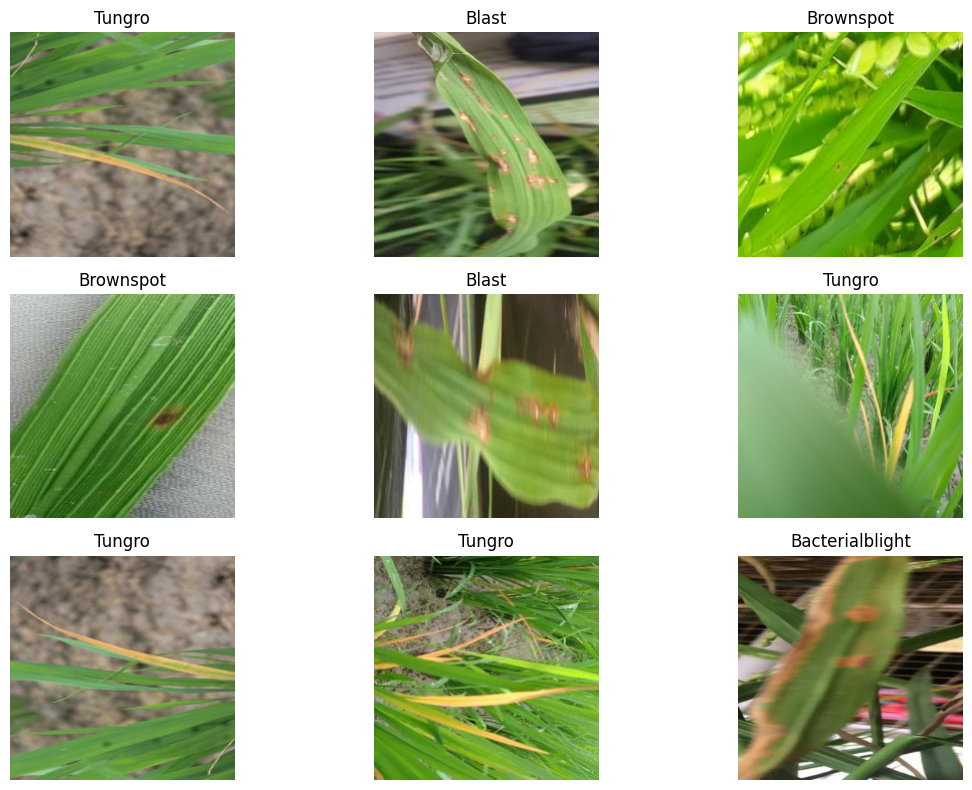

In [53]:
display_mobilenet_images(
    val_images,
    val_labels
)

In [54]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

In [55]:
def extract_color_features(image_path):
    """
    Extract statistical colour features from an image.

    Features:
        - RGB mean and standard deviation
        - HSV mean and standard deviation

    Returns:
        Dictionary containing colour features.
    """

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    )

    if image is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    # OpenCV loads images as BGR.
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Convert RGB image to HSV.
    image_hsv = cv2.cvtColor(
        image_rgb,
        cv2.COLOR_RGB2HSV
    )

    features = {}

    # RGB statistics
    rgb_channels = ["R", "G", "B"]

    for index, channel in enumerate(rgb_channels):
        features[f"{channel}_mean"] = np.mean(
            image_rgb[:, :, index]
        )

        features[f"{channel}_std"] = np.std(
            image_rgb[:, :, index]
        )

    # HSV statistics
    hsv_channels = ["H", "S", "V"]

    for index, channel in enumerate(hsv_channels):
        features[f"{channel}_mean"] = np.mean(
            image_hsv[:, :, index]
        )

        features[f"{channel}_std"] = np.std(
            image_hsv[:, :, index]
        )

    return features

In [56]:
sample_path = train_df.iloc[0]["image_path"]

sample_color_features = extract_color_features(
    sample_path
)

print(sample_color_features)

{'R_mean': np.float64(89.43586666666667), 'R_std': np.float64(60.967701633496986), 'G_mean': np.float64(85.60853333333333), 'G_std': np.float64(56.11609729900246), 'B_mean': np.float64(74.75208888888889), 'B_std': np.float64(50.229667263623405), 'H_mean': np.float64(59.33722222222222), 'H_std': np.float64(49.729154572606326), 'S_mean': np.float64(71.41531111111111), 'S_std': np.float64(35.65228160086889), 'V_mean': np.float64(95.96912222222223), 'V_std': np.float64(60.20803777926587)}


In [57]:
from skimage.feature import graycomatrix, graycoprops


def extract_texture_features(image_path):
    """
    Extract texture features using GLCM.

    Features:
        - Contrast
        - Dissimilarity
        - Homogeneity
        - Energy
        - Correlation

    Returns:
        Dictionary containing texture features.
    """

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    # Reduce the number of gray levels.
    image = cv2.resize(
        image,
        (128, 128)
    )

    image = (image / 32).astype(np.uint8)

    # Create the GLCM.
    glcm = graycomatrix(
        image,
        distances=[1],
        angles=[0],
        levels=8,
        symmetric=True,
        normed=True
    )

    features = {
        "texture_contrast": graycoprops(
            glcm, "contrast"
        )[0, 0],

        "texture_dissimilarity": graycoprops(
            glcm, "dissimilarity"
        )[0, 0],

        "texture_homogeneity": graycoprops(
            glcm, "homogeneity"
        )[0, 0],

        "texture_energy": graycoprops(
            glcm, "energy"
        )[0, 0],

        "texture_correlation": graycoprops(
            glcm, "correlation"
        )[0, 0]
    }

    return features

In [58]:
sample_texture_features = extract_texture_features(
    sample_path
)

print(sample_texture_features)

{'texture_contrast': np.float64(0.6766732283464567), 'texture_dissimilarity': np.float64(0.4157234251968504), 'texture_homogeneity': np.float64(0.816455493442814), 'texture_energy': np.float64(0.3213770669162323), 'texture_correlation': np.float64(0.8896818754015047)}


In [59]:
# ============================================================
# FINAL CLASSICAL ML DATASET
# Use the deduplicated dataset established during data cleaning
# ============================================================

# Use one representative image from each exact-duplicate group
final_ml_df = deduplicated_df.copy()

# Recreate image paths and labels for Member 4 feature extraction
image_paths = final_ml_df["image_path"].tolist()
labels = final_ml_df["class_name"].tolist()

print("Images used for classical ML:", len(image_paths))
print("Number of labels:", len(labels))
print("Classes:", sorted(set(labels)))

Images used for classical ML: 4794
Number of labels: 4794
Classes: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


In [60]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops
from skimage import img_as_ubyte

In [61]:
def texture_features(img_bgr):
    """
    Extract the four GLCM texture features used in Progress I.
    """

    gray = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2GRAY
    )

    gray = img_as_ubyte(gray)

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(
        glcm,
        "contrast"
    )[0, 0]

    homogeneity = graycoprops(
        glcm,
        "homogeneity"
    )[0, 0]

    energy = graycoprops(
        glcm,
        "energy"
    )[0, 0]

    correlation = graycoprops(
        glcm,
        "correlation"
    )[0, 0]

    return (
        contrast,
        homogeneity,
        energy,
        correlation
    )

In [62]:
def get_leaf_roi_final(img_bgr):
    """
    Create the final leaf ROI used in Progress I.
    """

    hsv = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2HSV
    )

    lower_green = np.array(
        [25, 40, 40]
    )

    upper_green = np.array(
        [95, 255, 255]
    )

    green_mask = cv2.inRange(
        hsv,
        lower_green,
        upper_green
    )

    kernel = np.ones(
        (7, 7),
        np.uint8
    )

    green_mask = cv2.morphologyEx(
        green_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    num_labels, label_map, stats, _ = (
        cv2.connectedComponentsWithStats(
            green_mask,
            connectivity=8
        )
    )

    if num_labels <= 1:
        return green_mask

    largest_label = (
        1
        + np.argmax(
            stats[
                1:,
                cv2.CC_STAT_AREA
            ]
        )
    )

    leaf_roi = np.uint8(
        label_map == largest_label
    ) * 255

    leaf_roi = cv2.dilate(
        leaf_roi,
        np.ones((25, 25), np.uint8)
    )

    return leaf_roi


def lesion_count_final(
    img_bgr,
    min_area=80
):
    """
    Count disease-region contours inside
    the final leaf ROI.
    """

    hsv = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2HSV
    )

    lower_disease = np.array(
        [5, 40, 40]
    )

    upper_disease = np.array(
        [30, 255, 255]
    )

    disease_mask = cv2.inRange(
        hsv,
        lower_disease,
        upper_disease
    )

    leaf_roi = get_leaf_roi_final(
        img_bgr
    )

    disease_mask = cv2.bitwise_and(
        disease_mask,
        leaf_roi
    )

    kernel = np.ones(
        (3, 3),
        np.uint8
    )

    disease_mask = cv2.morphologyEx(
        disease_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    contours, _ = cv2.findContours(
        disease_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    valid_contours = [
        contour
        for contour in contours
        if cv2.contourArea(contour) >= min_area
    ]

    return len(valid_contours)


def lesion_area_ratio_final(img_bgr):
    """
    Calculate the final disease-area ratio
    used in Progress I.
    """

    hsv = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2HSV
    )

    lower_green = np.array(
        [25, 40, 40]
    )

    upper_green = np.array(
        [95, 255, 255]
    )

    green_mask = cv2.inRange(
        hsv,
        lower_green,
        upper_green
    )

    lower_disease = np.array(
        [5, 40, 40]
    )

    upper_disease = np.array(
        [30, 255, 255]
    )

    disease_mask = cv2.inRange(
        hsv,
        lower_disease,
        upper_disease
    )

    leaf_roi = get_leaf_roi_final(
        img_bgr
    )

    green_mask = cv2.bitwise_and(
        green_mask,
        leaf_roi
    )

    disease_mask = cv2.bitwise_and(
        disease_mask,
        leaf_roi
    )

    green_pixels = np.count_nonzero(
        green_mask
    )

    disease_pixels = np.count_nonzero(
        disease_mask
    )

    total = green_pixels + disease_pixels

    return (
        disease_pixels / total
        if total > 0
        else 0.0
    )

In [63]:
texture_results = []

for image_path, class_name in zip(
    image_paths,
    labels
):

    image = cv2.imread(
        image_path
    )

    if image is None:
        raise ValueError(
            f"Could not read: {image_path}"
        )

    (
        contrast,
        homogeneity,
        energy,
        correlation
    ) = texture_features(image)

    lesion_ratio = (
        lesion_area_ratio_final(
            image
        )
    )

    lesion_count = (
        lesion_count_final(
            image
        )
    )

    texture_results.append({
        "image_path": image_path,
        "class_name": class_name,
        "contrast": contrast,
        "homogeneity": homogeneity,
        "energy": energy,
        "correlation": correlation,
        "lesion_ratio_final": lesion_ratio,
        "lesion_count_final": lesion_count
    })

texture_df = pd.DataFrame(
    texture_results
)

print(
    "Feature table shape:",
    texture_df.shape
)

print(texture_df.head())

Feature table shape: (4794, 8)
                                          image_path       class_name  \
0  /content/rice_leaf_dataset/Bacterialblight/BAC...  Bacterialblight   
1  /content/rice_leaf_dataset/Bacterialblight/BAC...  Bacterialblight   
2  /content/rice_leaf_dataset/Bacterialblight/BAC...  Bacterialblight   
3  /content/rice_leaf_dataset/Bacterialblight/BAC...  Bacterialblight   
4  /content/rice_leaf_dataset/Bacterialblight/BAC...  Bacterialblight   

     contrast  homogeneity    energy  correlation  lesion_ratio_final  \
0   81.379855     0.310932  0.025391     0.981515            0.099582   
1  215.369922     0.291813  0.021947     0.958244            0.061480   
2   53.725786     0.262248  0.024605     0.978451            0.056524   
3   55.418606     0.388990  0.026124     0.993562            0.257032   
4   78.096957     0.433099  0.031552     0.987210            0.086427   

   lesion_count_final  
0                   7  
1                   5  
2                  

In [64]:
def color_features(img_bgr):
    """
    Extract mean HSV values from detected
    disease regions within the leaf ROI.
    """

    hsv = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2HSV
    )

    lower_disease = np.array(
        [5, 40, 40]
    )

    upper_disease = np.array(
        [30, 255, 255]
    )

    disease_mask = cv2.inRange(
        hsv,
        lower_disease,
        upper_disease
    )

    leaf_roi = get_leaf_roi_final(
        img_bgr
    )

    disease_mask = cv2.bitwise_and(
        disease_mask,
        leaf_roi
    )

    if np.count_nonzero(
        disease_mask
    ) == 0:
        return 0.0, 0.0, 0.0

    mean_h = (
        hsv[:, :, 0][
            disease_mask > 0
        ].mean()
    )

    mean_s = (
        hsv[:, :, 1][
            disease_mask > 0
        ].mean()
    )

    mean_v = (
        hsv[:, :, 2][
            disease_mask > 0
        ].mean()
    )

    return mean_h, mean_s, mean_v

In [65]:
mean_hs = []
mean_ss = []
mean_vs = []

for image_path in image_paths:

    image = cv2.imread(
        image_path
    )

    h, s, v = color_features(
        image
    )

    mean_hs.append(h)
    mean_ss.append(s)
    mean_vs.append(v)

texture_df["lesion_mean_h"] = mean_hs
texture_df["lesion_mean_s"] = mean_ss
texture_df["lesion_mean_v"] = mean_vs

In [66]:
feature_cols = [
    "contrast",
    "homogeneity",
    "energy",
    "correlation",
    "lesion_ratio_final",
    "lesion_count_final",
    "lesion_mean_h",
    "lesion_mean_s",
    "lesion_mean_v"
]

X = texture_df[
    feature_cols
].copy()

print(
    "Final feature matrix:",
    X.shape
)

print(
    "\nFeature names:"
)

for feature in feature_cols:
    print("-", feature)

Final feature matrix: (4794, 9)

Feature names:
- contrast
- homogeneity
- energy
- correlation
- lesion_ratio_final
- lesion_count_final
- lesion_mean_h
- lesion_mean_s
- lesion_mean_v


In [67]:
print("\nMissing values:")
print(X.isnull().sum())

print(
    "\nInfinite values:",
    np.isinf(
        X.to_numpy()
    ).sum()
)

print("\nSummary:")
print(
    X.describe().T
)


Missing values:
contrast              0
homogeneity           0
energy                0
correlation           0
lesion_ratio_final    0
lesion_count_final    0
lesion_mean_h         0
lesion_mean_s         0
lesion_mean_v         0
dtype: int64

Infinite values: 0

Summary:
                     count        mean         std        min         25%  \
contrast            4794.0   85.592286  114.675221   1.533790   15.484916   
homogeneity         4794.0    0.358269    0.140783   0.079545    0.248991   
energy              4794.0    0.032873    0.015666   0.010531    0.021834   
correlation         4794.0    0.971396    0.036709   0.665033    0.968615   
lesion_ratio_final  4794.0    0.157338    0.147741   0.001453    0.032728   
lesion_count_final  4794.0    7.616187    6.861659   0.000000    2.000000   
lesion_mean_h       4794.0   21.601419    3.427171  11.654279   19.086569   
lesion_mean_s       4794.0  103.842149   31.467685  49.975543   77.771165   
lesion_mean_v       4794.0  148

Correlation Matrix:


,contrast,homogeneity,energy,correlation,lesion_ratio_final,lesion_count_final,lesion_mean_h,lesion_mean_s,lesion_mean_v
contrast,1.000,-0.667,-0.509,-0.834,0.056,0.083,0.201,-0.089,0.242
homogeneity,-0.667,1.000,0.862,0.630,-0.225,-0.188,-0.132,0.104,-0.118
energy,-0.509,0.862,1.000,0.409,-0.308,-0.230,-0.106,0.123,-0.121
correlation,-0.834,0.630,0.409,1.000,-0.034,-0.162,-0.119,0.108,-0.093
lesion_ratio_final,0.056,-0.225,-0.308,-0.034,1.000,0.293,-0.325,-0.285,-0.191
lesion_count_final,0.083,-0.188,-0.230,-0.162,0.293,1.000,-0.339,-0.457,-0.213
lesion_mean_h,0.201,-0.132,-0.106,-0.119,-0.325,-0.339,1.000,0.473,0.425
lesion_mean_s,-0.089,0.104,0.123,0.108,-0.285,-0.457,0.473,1.000,-0.074
lesion_mean_v,0.242,-0.118,-0.121,-0.093,-0.191,-0.213,0.425,-0.074,1.000


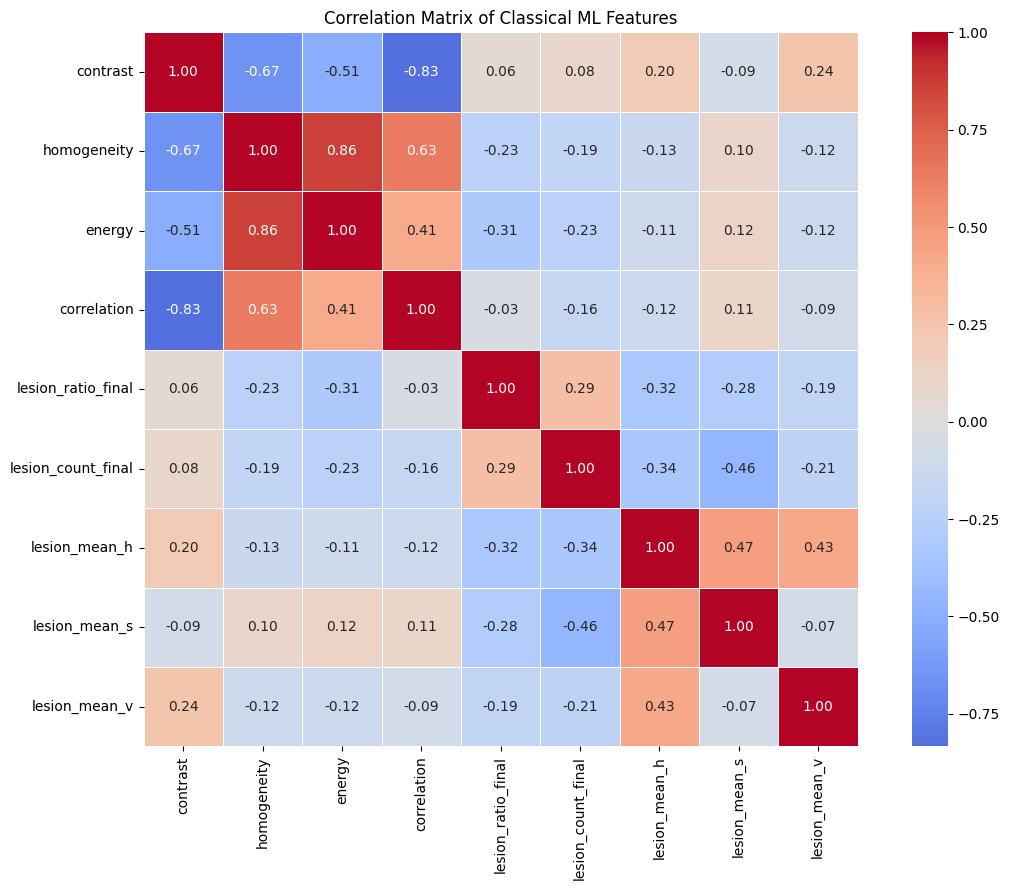

In [68]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Pearson correlation between all features
correlation_matrix = X[feature_cols].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(3))

# Visualize correlations
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix of Classical ML Features")
plt.tight_layout()
plt.show()

In [69]:
# ============================================================
# IDENTIFY HIGHLY CORRELATED FEATURE PAIRS
# ============================================================

correlation_threshold = 0.80

high_corr_pairs = []

for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):

        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) >= correlation_threshold:
            high_corr_pairs.append(
                (
                    feature_cols[i],
                    feature_cols[j],
                    corr_value
                )
            )

print("Highly correlated feature pairs:")

if high_corr_pairs:
    for feature_1, feature_2, corr_value in high_corr_pairs:
        print(
            f"{feature_1} <-> {feature_2}: "
            f"{corr_value:.3f}"
        )
else:
    print("No feature pairs have |correlation| >= 0.80.")

Highly correlated feature pairs:
contrast <-> correlation: -0.834
homogeneity <-> energy: 0.862


In [70]:
# ============================================================
# IQR OUTLIER ANALYSIS
# ============================================================

Q1 = X[feature_cols].quantile(0.25)
Q3 = X[feature_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    (X[feature_cols] < lower_bound) |
    (X[feature_cols] > upper_bound)
).sum()

outlier_percentage = (
    outlier_counts / len(X) * 100
)

outlier_summary = pd.DataFrame({
    "Outlier Count": outlier_counts,
    "Outlier Percentage": outlier_percentage.round(2)
})

print("IQR Outlier Summary:")
display(outlier_summary)

IQR Outlier Summary:


,Outlier Count,Outlier Percentage
contrast,497,10.37
homogeneity,0,0.00
energy,104,2.17
correlation,577,12.04
lesion_ratio_final,87,1.81
lesion_count_final,160,3.34
lesion_mean_h,2,0.04
lesion_mean_s,8,0.17
lesion_mean_v,207,4.32


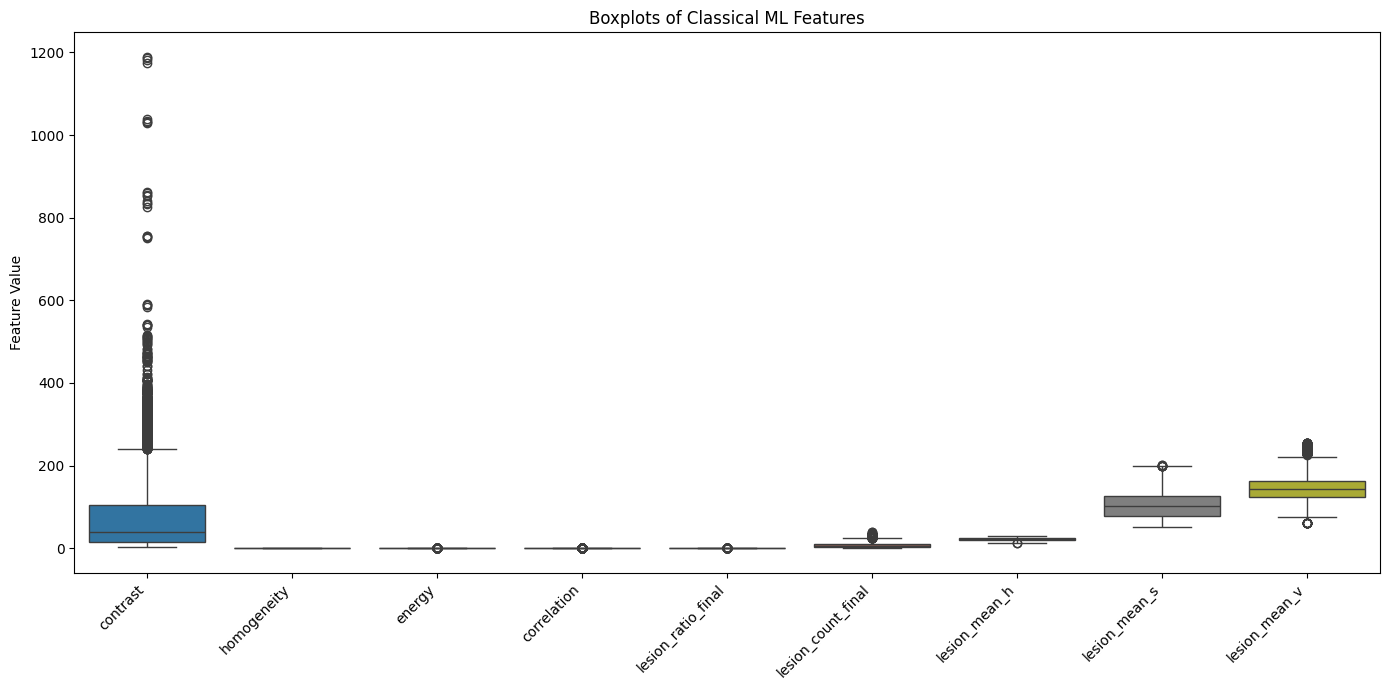

In [71]:
# ============================================================
# BOXPLOTS FOR OUTLIER VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=X[feature_cols]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title("Boxplots of Classical ML Features")
plt.ylabel("Feature Value")
plt.tight_layout()
plt.show()

In [72]:
print("X_train exists:", "X_train" in globals())
print("X_val exists:", "X_val" in globals())
print("X_test exists:", "X_test" in globals())

X_train exists: False
X_val exists: False
X_test exists: False


In [73]:
# ============================================================
# CLASSICAL ML - PREPARE LABELS AND STRATIFIED SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Step 1: Define the final 9 features
# ------------------------------------------------------------

feature_cols = [
    "contrast",
    "homogeneity",
    "energy",
    "correlation",
    "lesion_ratio_final",
    "lesion_count_final",
    "lesion_mean_h",
    "lesion_mean_s",
    "lesion_mean_v"
]

# ------------------------------------------------------------
# Step 2: Create feature matrix
# ------------------------------------------------------------

X = texture_df[feature_cols].copy()

print("Feature matrix shape:", X.shape)


# ------------------------------------------------------------
# Step 3: Create target labels
# ------------------------------------------------------------
# texture_df does not contain a "label" column.
# The labels were created from the deduplicated dataset
# using the "class_name" column.
#
# We use the existing labels list that was created during
# the final deduplicated feature-extraction pipeline.

y = pd.Series(
    labels,
    name="label"
).reset_index(drop=True)

# Make sure X and y have matching indexes
X = X.reset_index(drop=True)


# ------------------------------------------------------------
# Step 4: Verify X and y have the same number of samples
# ------------------------------------------------------------

print("Labels shape:", y.shape)

if len(X) != len(y):
    raise ValueError(
        f"Feature and label counts do not match: "
        f"X={len(X)}, y={len(y)}"
    )

print("\nX and y sizes match successfully.")


# ------------------------------------------------------------
# Step 5: Check class distribution
# ------------------------------------------------------------

print("\nOverall class distribution:")
print(y.value_counts())


# ------------------------------------------------------------
# Step 6: First stratified split
# 70% training
# 30% temporary
# ------------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# Step 7: Split temporary data equally
# 15% validation
# 15% test
# ------------------------------------------------------------

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


# ------------------------------------------------------------
# Step 8: Display final shapes
# ------------------------------------------------------------

print("\nFinal dataset split:")
print(
    "Training set:",
    X_train.shape,
    y_train.shape
)

print(
    "Validation set:",
    X_val.shape,
    y_val.shape
)

print(
    "Test set:",
    X_test.shape,
    y_test.shape
)


# ------------------------------------------------------------
# Step 9: Verify class distribution in each split
# ------------------------------------------------------------

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Feature matrix shape: (4794, 9)
Labels shape: (4794,)

X and y sizes match successfully.

Overall class distribution:
label
Bacterialblight    1326
Tungro             1308
Brownspot          1200
Blast               960
Name: count, dtype: int64

Final dataset split:
Training set: (3355, 9) (3355,)
Validation set: (719, 9) (719,)
Test set: (720, 9) (720,)

Training class distribution:
label
Bacterialblight    928
Tungro             915
Brownspot          840
Blast              672
Name: count, dtype: int64

Validation class distribution:
label
Bacterialblight    199
Tungro             196
Brownspot          180
Blast              144
Name: count, dtype: int64

Test class distribution:
label
Bacterialblight    199
Tungro             197
Brownspot          180
Blast              144
Name: count, dtype: int64


In [74]:
# ============================================================
# CHECK CLASS DISTRIBUTION AFTER SPLITTING
# ============================================================

print("Training class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training class distribution:
label
Bacterialblight    928
Tungro             915
Brownspot          840
Blast              672
Name: count, dtype: int64

Validation class distribution:
label
Bacterialblight    199
Tungro             196
Brownspot          180
Blast              144
Name: count, dtype: int64

Test class distribution:
label
Bacterialblight    199
Tungro             197
Brownspot          180
Blast              144
Name: count, dtype: int64


In [75]:
# ============================================================
# FEATURE STANDARDIZATION
# Fit scaler ONLY on training data
# ============================================================

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (3355, 9)
Scaled validation shape: (719, 9)
Scaled test shape: (720, 9)


In [76]:
# ============================================================
# VERIFY STANDARDIZATION
# ============================================================

print("Training feature means:")
print(np.round(X_train_scaled.mean(axis=0), 4))

print("\nTraining feature standard deviations:")
print(np.round(X_train_scaled.std(axis=0), 4))

Training feature means:
[ 0. -0. -0.  0. -0.  0. -0.  0.  0.]

Training feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Model 6: MobileNetV2 Transfer Learning

This section develops a MobileNetV2-based transfer learning model
using the image datasets and preprocessing pipeline already created
in the master pipeline.

The existing train, validation, and test datasets are reused without
repeating preprocessing or data splitting.

In [77]:
# ============================================================
# MOBILENETV2 - IMPORTS
# ============================================================

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [78]:
# ============================================================
# VERIFY EXISTING MOBILENETV2 DATASETS
# ============================================================

required_datasets = [
    "train_mobilenet_ds",
    "val_mobilenet_ds",
    "test_mobilenet_ds"
]

for dataset_name in required_datasets:
    if dataset_name not in globals():
        raise NameError(
            f"{dataset_name} was not created by the master pipeline."
        )

    print(f"✓ {dataset_name} is available.")

print("\nExisting MobileNetV2 datasets are ready.")

✓ train_mobilenet_ds is available.
✓ val_mobilenet_ds is available.
✓ test_mobilenet_ds is available.

Existing MobileNetV2 datasets are ready.


In [79]:
# ============================================================
# VERIFY MOBILE NETV2 INPUT DATA
# ============================================================

sample_images, sample_labels = next(
    iter(train_mobilenet_ds)
)

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)

print(
    "Minimum pixel value:",
    tf.reduce_min(sample_images).numpy()
)

print(
    "Maximum pixel value:",
    tf.reduce_max(sample_images).numpy()
)

print(
    "Unique labels:",
    tf.sort(
        tf.unique(
            tf.reshape(sample_labels, [-1])
        ).y
    ).numpy()
)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: -1.0
Maximum pixel value: 0.9999746
Unique labels: [0 1 2 3]


## 6.1 Baseline MobileNetV2 Model

MobileNetV2 is a convolutional neural network architecture that was
pre-trained on a large image dataset. Transfer learning allows us to
reuse the learned visual features from the pre-trained network and
adapt them to the four rice leaf disease classes.

For the baseline model, the pre-trained MobileNetV2 feature extractor
is frozen. Only the newly added classification layers are trained.

This provides a strong starting point before considering further
fine-tuning.

In [80]:
# ============================================================
# MOBILENETV2 BASELINE MODEL
# ============================================================

base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the pre-trained convolutional base
base_model.trainable = False

# Build the classification model
mobilenet_baseline = models.Sequential(
    [
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ],
    name="MobileNetV2_Baseline"
)

mobilenet_baseline.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [81]:
# ============================================================
# COMPILE BASELINE MOBILENETV2
# ============================================================

mobilenet_baseline.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Baseline MobileNetV2 compiled successfully.")

Baseline MobileNetV2 compiled successfully.


In [82]:
# ============================================================
# BASELINE CALLBACKS
# ============================================================

baseline_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

print("Callbacks configured successfully.")

Callbacks configured successfully.


In [83]:
# ============================================================
# TRAIN BASELINE MOBILENETV2
# ============================================================

BASELINE_EPOCHS = 20

mobilenet_baseline_history = mobilenet_baseline.fit(
    train_mobilenet_ds,
    validation_data=val_mobilenet_ds,
    epochs=BASELINE_EPOCHS,
    callbacks=baseline_callbacks,
    verbose=1
)

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 73s 574ms/step - accuracy: 0.7639 - loss: 0.5971 - val_accuracy: 0.9124 - val_loss: 0.2784 - learning_rate: 0.0010
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 48s 454ms/step - accuracy: 0.9025 - loss: 0.2644 - val_accuracy: 0.9040 - val_loss: 0.2317 - learning_rate: 0.0010
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 49s 465ms/step - accuracy: 0.9344 - loss: 0.1977 - val_accuracy: 0.9416 - val_loss: 0.1613 - learning_rate: 0.0010
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 82s 463ms/step - accuracy: 0.9463 - loss: 0.1643 - val_accuracy: 0.9499 - val_loss: 0.1365 - learning_rate: 0.0010
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 48s 457ms/step - accuracy: 0.9490 - loss: 0.1559 - val_accuracy: 0.9499 - val_loss: 0.1314 - learning_rate: 0.0010
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 49s 471ms/step - accuracy: 0.9499 - loss: 0.1416 - val_accuracy: 0.9513 - val_loss: 0.1221 - learning_rate: 0.0010
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 47s 452ms/step - accuracy: 0.9

### 6.2 Baseline Training History

The training and validation accuracy and loss are visualized to
determine how the MobileNetV2 baseline learned over the training
epochs and whether there are signs of overfitting or underfitting.

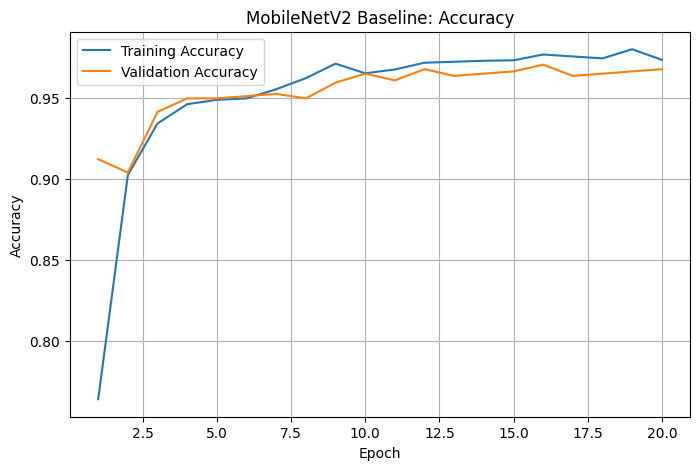

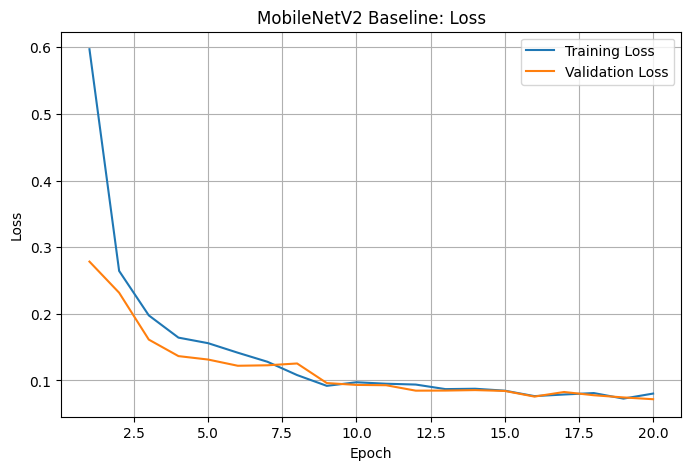

In [84]:
# ============================================================
# BASELINE LEARNING CURVES
# ============================================================

import matplotlib.pyplot as plt

history = mobilenet_baseline_history.history

epochs = range(1, len(history["accuracy"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["accuracy"], label="Training Accuracy")
plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Baseline: Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["loss"], label="Training Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Baseline: Loss")
plt.legend()
plt.grid(True)
plt.show()

In [85]:
# ============================================================
# BEST BASELINE VALIDATION PERFORMANCE
# ============================================================

best_epoch = (
    history["val_accuracy"].index(max(history["val_accuracy"])) + 1
)

best_val_accuracy = max(history["val_accuracy"])
best_val_loss = min(history["val_loss"])

print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best validation-loss epoch: {history['val_loss'].index(best_val_loss) + 1}")
print(f"Best validation loss: {best_val_loss:.4f}")

Best validation accuracy: 0.9708
Best validation-loss epoch: 20
Best validation loss: 0.0718


In [86]:
# ============================================================
# BASELINE VALIDATION PREDICTIONS
# ============================================================

import numpy as np

val_probabilities = mobilenet_baseline.predict(
    val_mobilenet_ds,
    verbose=1
)

val_predictions = np.argmax(
    val_probabilities,
    axis=1
)

val_true_labels = np.concatenate(
    [labels.numpy() for _, labels in val_mobilenet_ds],
    axis=0
)

print("Validation samples:", len(val_true_labels))
print("Predictions:", len(val_predictions))

23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step
Validation samples: 719
Predictions: 719


In [87]:
# ============================================================
# BASELINE VALIDATION CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

val_accuracy = accuracy_score(
    val_true_labels,
    val_predictions
)

val_precision = precision_score(
    val_true_labels,
    val_predictions,
    average="weighted",
    zero_division=0
)

val_recall = recall_score(
    val_true_labels,
    val_predictions,
    average="weighted",
    zero_division=0
)

val_f1 = f1_score(
    val_true_labels,
    val_predictions,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1 Score : {val_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        val_true_labels,
        val_predictions,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

Accuracy : 0.9680
Precision: 0.9681
Recall   : 0.9680
F1 Score : 0.9678

Classification Report:

                 precision    recall  f1-score   support

Bacterialblight       0.94      0.97      0.96       199
          Blast       0.94      0.90      0.92       144
      Brownspot       0.99      0.98      0.99       180
         Tungro       1.00      1.00      1.00       196

       accuracy                           0.97       719
      macro avg       0.97      0.96      0.96       719
   weighted avg       0.97      0.97      0.97       719



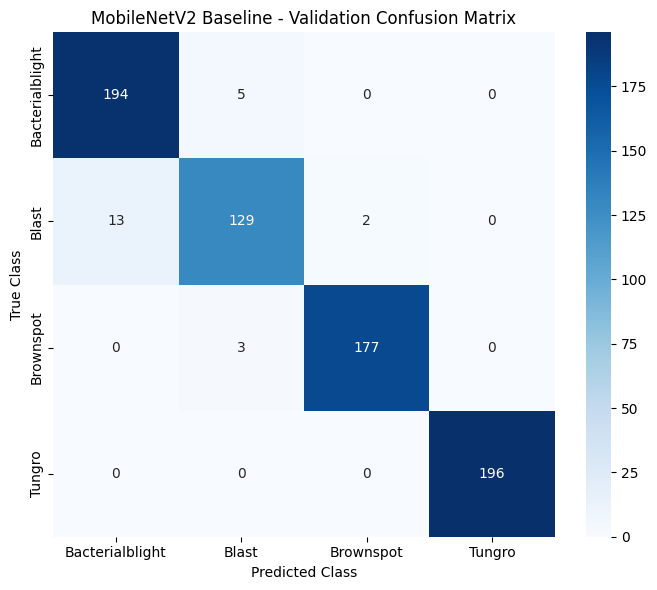

In [88]:
# ============================================================
# BASELINE VALIDATION CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    val_true_labels,
    val_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("MobileNetV2 Baseline - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

### 6.3 MobileNetV2 Fine-Tuning

The baseline MobileNetV2 used a frozen ImageNet-pretrained feature
extractor. Although this achieved strong validation performance,
the confusion matrix showed that Blast was the main source of errors.

Fine-tuning allows the later layers of MobileNetV2 to adapt their
learned visual representations to the rice leaf disease dataset.

Only the later part of the convolutional base is unfrozen, while
earlier layers remain frozen. Batch Normalization layers are kept
frozen to maintain stable pretrained statistics.

A much smaller learning rate is used during fine-tuning to avoid
destroying useful pretrained features.

In [89]:
# ============================================================
# MOBILENETV2 FINE-TUNING MODEL
# ============================================================

fine_tune_base = MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Initially freeze the entire pretrained base
fine_tune_base.trainable = True

# Freeze all layers except the final 30 layers.
fine_tune_at = len(fine_tune_base.layers) - 30

for layer in fine_tune_base.layers[:fine_tune_at]:
    layer.trainable = False

# Keep Batch Normalization layers frozen
for layer in fine_tune_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

mobilenet_finetuned = models.Sequential(
    [
        fine_tune_base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ],
    name="MobileNetV2_FineTuned"
)

mobilenet_finetuned.summary()

Model: "MobileNetV2_FineTuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 1,515,844 (5.78 MB)

 Non-trainable params: 747,264 (2.85 MB)

In [90]:
# ============================================================
# CHECK TRAINABLE LAYERS
# ============================================================

trainable_layers = [
    layer.name
    for layer in mobilenet_finetuned.layers
    if layer.trainable
]

print("Trainable top-level layers:")
for layer_name in trainable_layers:
    print("✓", layer_name)

print(
    "\nTotal trainable parameters:",
    sum(
        tf.size(variable).numpy()
        for variable in mobilenet_finetuned.trainable_variables
    )
)

print(
    "Total trainable variables:",
    len(mobilenet_finetuned.trainable_variables)
)

Trainable top-level layers:
✓ mobilenetv2_1.00_224
✓ global_average_pooling2d_1
✓ dropout_1
✓ dense_1

Total trainable parameters: 1515844
Total trainable variables: 12


In [91]:
# ============================================================
# COMPILE FINE-TUNED MOBILENETV2
# ============================================================

mobilenet_finetuned.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuned MobileNetV2 compiled successfully.")

Fine-tuned MobileNetV2 compiled successfully.


In [92]:
# ============================================================
# FINE-TUNING CALLBACKS
# ============================================================

fine_tune_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )
]

print("Fine-tuning callbacks configured.")

Fine-tuning callbacks configured.


In [93]:
# ============================================================
# TRAIN FINE-TUNED MOBILENETV2
# ============================================================

FINE_TUNE_EPOCHS = 10

mobilenet_finetuned_history = mobilenet_finetuned.fit(
    train_mobilenet_ds,
    validation_data=val_mobilenet_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks,
    verbose=1
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 78s 583ms/step - accuracy: 0.6936 - loss: 0.7619 - val_accuracy: 0.8595 - val_loss: 0.3726 - learning_rate: 1.0000e-05
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 51s 486ms/step - accuracy: 0.8739 - loss: 0.3385 - val_accuracy: 0.9318 - val_loss: 0.2043 - learning_rate: 1.0000e-05
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 82s 491ms/step - accuracy: 0.9252 - loss: 0.2235 - val_accuracy: 0.9624 - val_loss: 0.1352 - learning_rate: 1.0000e-05
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 82s 489ms/step - accuracy: 0.9458 - loss: 0.1679 - val_accuracy: 0.9569 - val_loss: 0.1266 - learning_rate: 1.0000e-05
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 49s 470ms/step - accuracy: 0.9595 - loss: 0.1292 - val_accuracy: 0.9791 - val_loss: 0.0813 - learning_rate: 1.0000e-05
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 51s 484ms/step - accuracy: 0.9708 - loss: 0.1005 - val_accuracy: 0.9847 - val_loss: 0.0642 - learning_rate: 1.0000e-05
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 82s 48

### 6.4 Fine-Tuned MobileNetV2 Training History

The training history of the fine-tuned MobileNetV2 model is examined
to determine whether fine-tuning improved validation performance and
whether there are signs of overfitting.

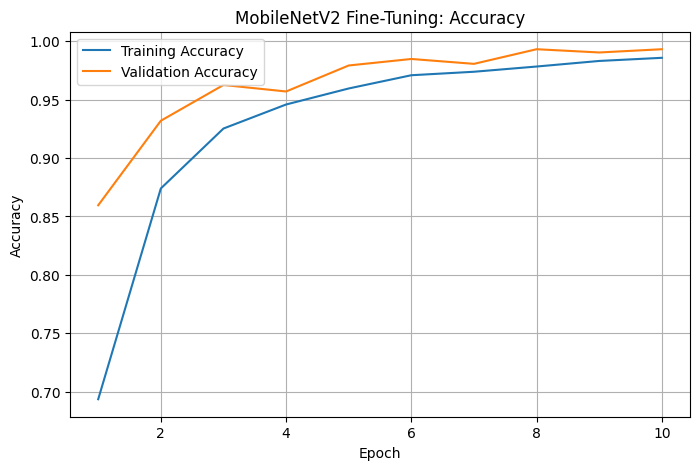

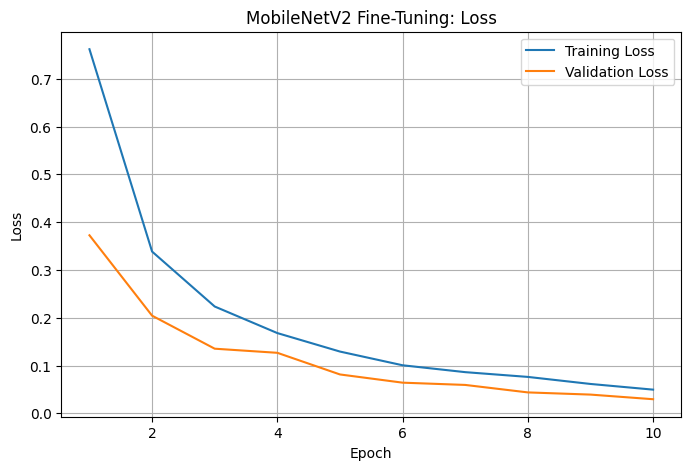

In [94]:
# ============================================================
# FINE-TUNED LEARNING CURVES
# ============================================================

fine_tune_history = mobilenet_finetuned_history.history

fine_tune_epochs = range(
    1,
    len(fine_tune_history["accuracy"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_epochs,
    fine_tune_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    fine_tune_epochs,
    fine_tune_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Fine-Tuning: Accuracy")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_epochs,
    fine_tune_history["loss"],
    label="Training Loss"
)

plt.plot(
    fine_tune_epochs,
    fine_tune_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Fine-Tuning: Loss")
plt.legend()
plt.grid(True)
plt.show()

In [95]:
# ============================================================
# BEST FINE-TUNING VALIDATION RESULTS
# ============================================================

best_fine_tune_accuracy = max(
    fine_tune_history["val_accuracy"]
)

best_fine_tune_accuracy_epoch = (
    fine_tune_history["val_accuracy"].index(
        best_fine_tune_accuracy
    ) + 1
)

best_fine_tune_loss = min(
    fine_tune_history["val_loss"]
)

best_fine_tune_loss_epoch = (
    fine_tune_history["val_loss"].index(
        best_fine_tune_loss
    ) + 1
)

print(
    f"Best validation accuracy: "
    f"{best_fine_tune_accuracy:.4f}"
)

print(
    f"Best validation accuracy epoch: "
    f"{best_fine_tune_accuracy_epoch}"
)

print(
    f"Best validation loss: "
    f"{best_fine_tune_loss:.4f}"
)

print(
    f"Best validation-loss epoch: "
    f"{best_fine_tune_loss_epoch}"
)

Best validation accuracy: 0.9930
Best validation accuracy epoch: 8
Best validation loss: 0.0295
Best validation-loss epoch: 10


In [96]:
# ============================================================
# FINE-TUNED VALIDATION PREDICTIONS
# ============================================================

fine_tune_val_probabilities = (
    mobilenet_finetuned.predict(
        val_mobilenet_ds,
        verbose=1
    )
)

fine_tune_val_predictions = np.argmax(
    fine_tune_val_probabilities,
    axis=1
)

fine_tune_val_true_labels = np.concatenate(
    [
        labels.numpy()
        for _, labels in val_mobilenet_ds
    ],
    axis=0
)

print(
    "Validation samples:",
    len(fine_tune_val_true_labels)
)

print(
    "Predictions:",
    len(fine_tune_val_predictions)
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 283ms/step
Validation samples: 719
Predictions: 719


In [97]:
# ============================================================
# FINE-TUNED VALIDATION METRICS
# ============================================================

fine_tune_val_accuracy = accuracy_score(
    fine_tune_val_true_labels,
    fine_tune_val_predictions
)

fine_tune_val_precision = precision_score(
    fine_tune_val_true_labels,
    fine_tune_val_predictions,
    average="weighted",
    zero_division=0
)

fine_tune_val_recall = recall_score(
    fine_tune_val_true_labels,
    fine_tune_val_predictions,
    average="weighted",
    zero_division=0
)

fine_tune_val_f1 = f1_score(
    fine_tune_val_true_labels,
    fine_tune_val_predictions,
    average="weighted",
    zero_division=0
)

print(
    f"Accuracy : {fine_tune_val_accuracy:.4f}"
)

print(
    f"Precision: {fine_tune_val_precision:.4f}"
)

print(
    f"Recall   : {fine_tune_val_recall:.4f}"
)

print(
    f"F1 Score : {fine_tune_val_f1:.4f}"
)

print("\nClassification Report:\n")

print(
    classification_report(
        fine_tune_val_true_labels,
        fine_tune_val_predictions,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

Accuracy : 0.9930
Precision: 0.9931
Recall   : 0.9930
F1 Score : 0.9930

Classification Report:

                 precision    recall  f1-score   support

Bacterialblight       0.99      1.00      0.99       199
          Blast       0.99      0.97      0.98       144
      Brownspot       0.99      0.99      0.99       180
         Tungro       1.00      1.00      1.00       196

       accuracy                           0.99       719
      macro avg       0.99      0.99      0.99       719
   weighted avg       0.99      0.99      0.99       719



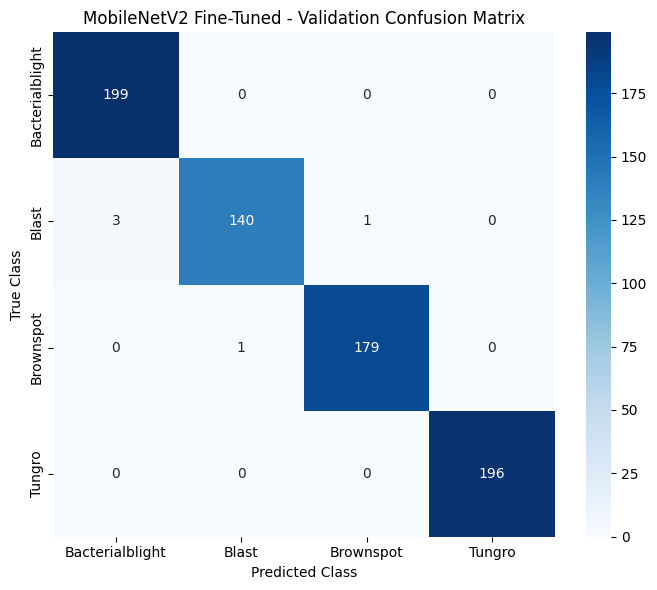

In [98]:
# ============================================================
# FINE-TUNED VALIDATION CONFUSION MATRIX
# ============================================================

fine_tune_cm = confusion_matrix(
    fine_tune_val_true_labels,
    fine_tune_val_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    fine_tune_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.title(
    "MobileNetV2 Fine-Tuned - Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

### 6.5 Final Test Evaluation

The fine-tuned MobileNetV2 model was selected using validation
performance. The test dataset has remained untouched throughout
training and model selection.

The selected model is now evaluated once on the held-out test set
to obtain the final performance estimate.

In [99]:
# ============================================================
# FINAL MOBILENETV2 TEST PREDICTIONS
# ============================================================

test_probabilities = mobilenet_finetuned.predict(
    test_mobilenet_ds,
    verbose=1
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

test_true_labels = np.concatenate(
    [
        labels.numpy()
        for _, labels in test_mobilenet_ds
    ],
    axis=0
)

print("Test samples:", len(test_true_labels))
print("Predictions:", len(test_predictions))

23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 384ms/step
Test samples: 720
Predictions: 720


In [100]:
# ============================================================
# FINAL MOBILENETV2 TEST METRICS
# ============================================================

test_accuracy = accuracy_score(
    test_true_labels,
    test_predictions
)

test_precision = precision_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        test_true_labels,
        test_predictions,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

Accuracy : 0.9931
Precision: 0.9931
Recall   : 0.9931
F1 Score : 0.9931

Classification Report:

                 precision    recall  f1-score   support

Bacterialblight       0.99      1.00      0.99       199
          Blast       0.99      0.99      0.99       144
      Brownspot       1.00      0.98      0.99       180
         Tungro       1.00      1.00      1.00       197

       accuracy                           0.99       720
      macro avg       0.99      0.99      0.99       720
   weighted avg       0.99      0.99      0.99       720



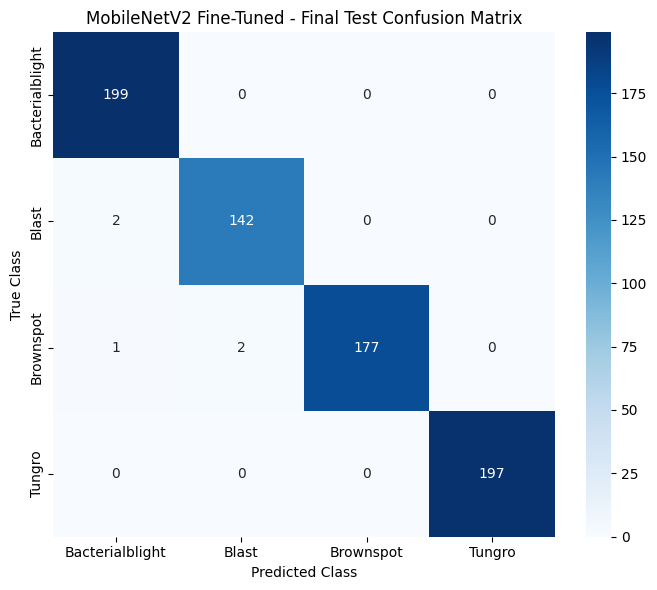

In [101]:
# ============================================================
# FINAL MOBILENETV2 TEST CONFUSION MATRIX
# ============================================================

test_cm = confusion_matrix(
    test_true_labels,
    test_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(
    "MobileNetV2 Fine-Tuned - Final Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

## 6.6 Final MobileNetV2 Results and Conclusion

The frozen MobileNetV2 baseline achieved a validation accuracy of
96.80% and a weighted F1-score of 96.78%.

Fine-tuning the final 30 layers of MobileNetV2, while keeping Batch
Normalization layers frozen, substantially improved validation
performance to 99.30% accuracy and 99.30% weighted F1-score.

The fine-tuned model was therefore selected as the final MobileNetV2
configuration.

The selected model was then evaluated once on the untouched test
dataset containing 720 images.

Final test performance:

- Accuracy: 99.31%
- Precision: 99.31%
- Recall: 99.31%
- Weighted F1-score: 99.31%

The final confusion matrix contained 715 correct predictions and
5 misclassifications. Bacterial Blight and Tungro were classified
without errors, while the remaining errors mainly involved
confusion between Blast, Brown Spot, and Bacterial Blight.

These results demonstrate that fine-tuning the pretrained MobileNetV2
feature extractor was effective for adapting the model to the rice
leaf disease classification task.